In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils import compile_df

# Update rc parameters for larger font sizes
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)
COLORS_RGB = {
    "REJ-ABC": [74, 140, 251],
    "NLE": [96, 208, 152],
    "NPE": [204, 102, 204],
    "NRE": [255, 202, 88],
    "SMC-ABC": [33, 95, 198],
    "SNLE": [51, 153, 102],
    "SNPE": [153, 0, 153],
    "SNRE": [255, 166, 10],
    "PRIOR": [100, 100, 100],
    "POSTERIOR": [10, 10, 10],
    "TRUE": [249, 33, 0],
}

# Convert RGB to normalized RGB for matplotlib
COLORS = {key: [val / 255 for val in value] for key, value in COLORS_RGB.items()}

In [8]:
df = compile_df(basepath="~/results/benchmarking_sbi_023/multirun/")
df.head()
# save the dataframe to a csv file
df.to_csv("re-sbibm_sbi_023.csv")

0it [00:00, ?it/s]

In [4]:
old_df = pd.read_csv("~/results/benchmarking_sbi/results/main_paper.csv")


# Convert num_simulations column to int in the old DataFrame
def convert_num_simulations(value):
    try:
        return int(value)
    except ValueError:
        if "³" in value:
            return int(value.replace("³", "")) * 100
        elif "⁴" in value:
            return int(value.replace("⁴", "")) * 1000
        elif "⁵" in value:
            return int(value.replace("⁵", "")) * 10000
        else:
            raise


old_df["num_simulations"] = old_df["num_simulations"].apply(convert_num_simulations)
old_df.head()

,task,num_simulations,num_observation,algorithm,C2ST,MMD,MEDDIST,NLTP,RT,KSD,folder
0,bernoulli_glm,1000,3,NRE,0.88065,0.205537,15.867109,NaN,5.101165,10.142339,09ce89a2-3a5b-49d8-8942-f2a5f925674d
1,bernoulli_glm,100000,6,SNRE,0.51855,0.000772,13.434448,NaN,131.694385,11.911603,6d4b9630-51ae-497d-b74f-581b108910b6
2,gaussian_mixture,10000,6,REJ-ABC,0.73655,0.073963,1.363378,NaN,0.016787,8.737809,6b3342b4-10a4-4933-8ad5-781e97eff7be
3,two_moons,10000,5,SMC-ABC,0.79925,0.022376,0.096044,NaN,0.040241,inf,0d71ce91-5f5e-4d14-b68d-53cd6710ec17
4,bernoulli_glm_raw,10000,2,SNLE,0.99150,0.700233,4.242641,NaN,47.109452,12.964170,be9320d9-53d5-44c1-9f25-6889222b5a61


In [5]:
def preprocess_dataframe(df, tasks, algorithms):
    """
    Preprocess the DataFrame by filtering, grouping, and calculating SEM.

    Parameters:
    df (pd.DataFrame): The DataFrame to preprocess.
    tasks (list): List of tasks to include.
    algorithms (list): List of algorithms to include.

    Returns:
    pd.DataFrame: The preprocessed DataFrame.
    """
    # Filter the DataFrame
    df_filtered = df[df["task"].isin(tasks) & df["algorithm"].isin(algorithms)]

    # Group the data and calculate mean, std, and count
    grouped = (
        df_filtered.groupby(["task", "algorithm", "num_simulations"])["C2ST"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Calculate SEM
    grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"])

    return grouped

In [6]:
# Define the order of algorithms and tasks
algorithms_order = ["REJ-ABC", "NLE", "NPE", "NRE", "SMC-ABC", "SNLE", "SNPE", "SNRE"]
tasks_order = [
    "gaussian_linear",
    "gaussian_linear_uniform",
    "slcp",
    "slcp_distractors",
    "bernoulli_glm",
    "bernoulli_glm_raw",
    "gaussian_mixture",
    "two_moons",
]

# Preprocess the current and old DataFrames
# List of DataFrames to process
dataframes = [df, old_df]  # Add more DataFrames as needed

# Preprocess each DataFrame
grouped_dataframes = [
    preprocess_dataframe(df, tasks_order, algorithms_order) for df in dataframes
]

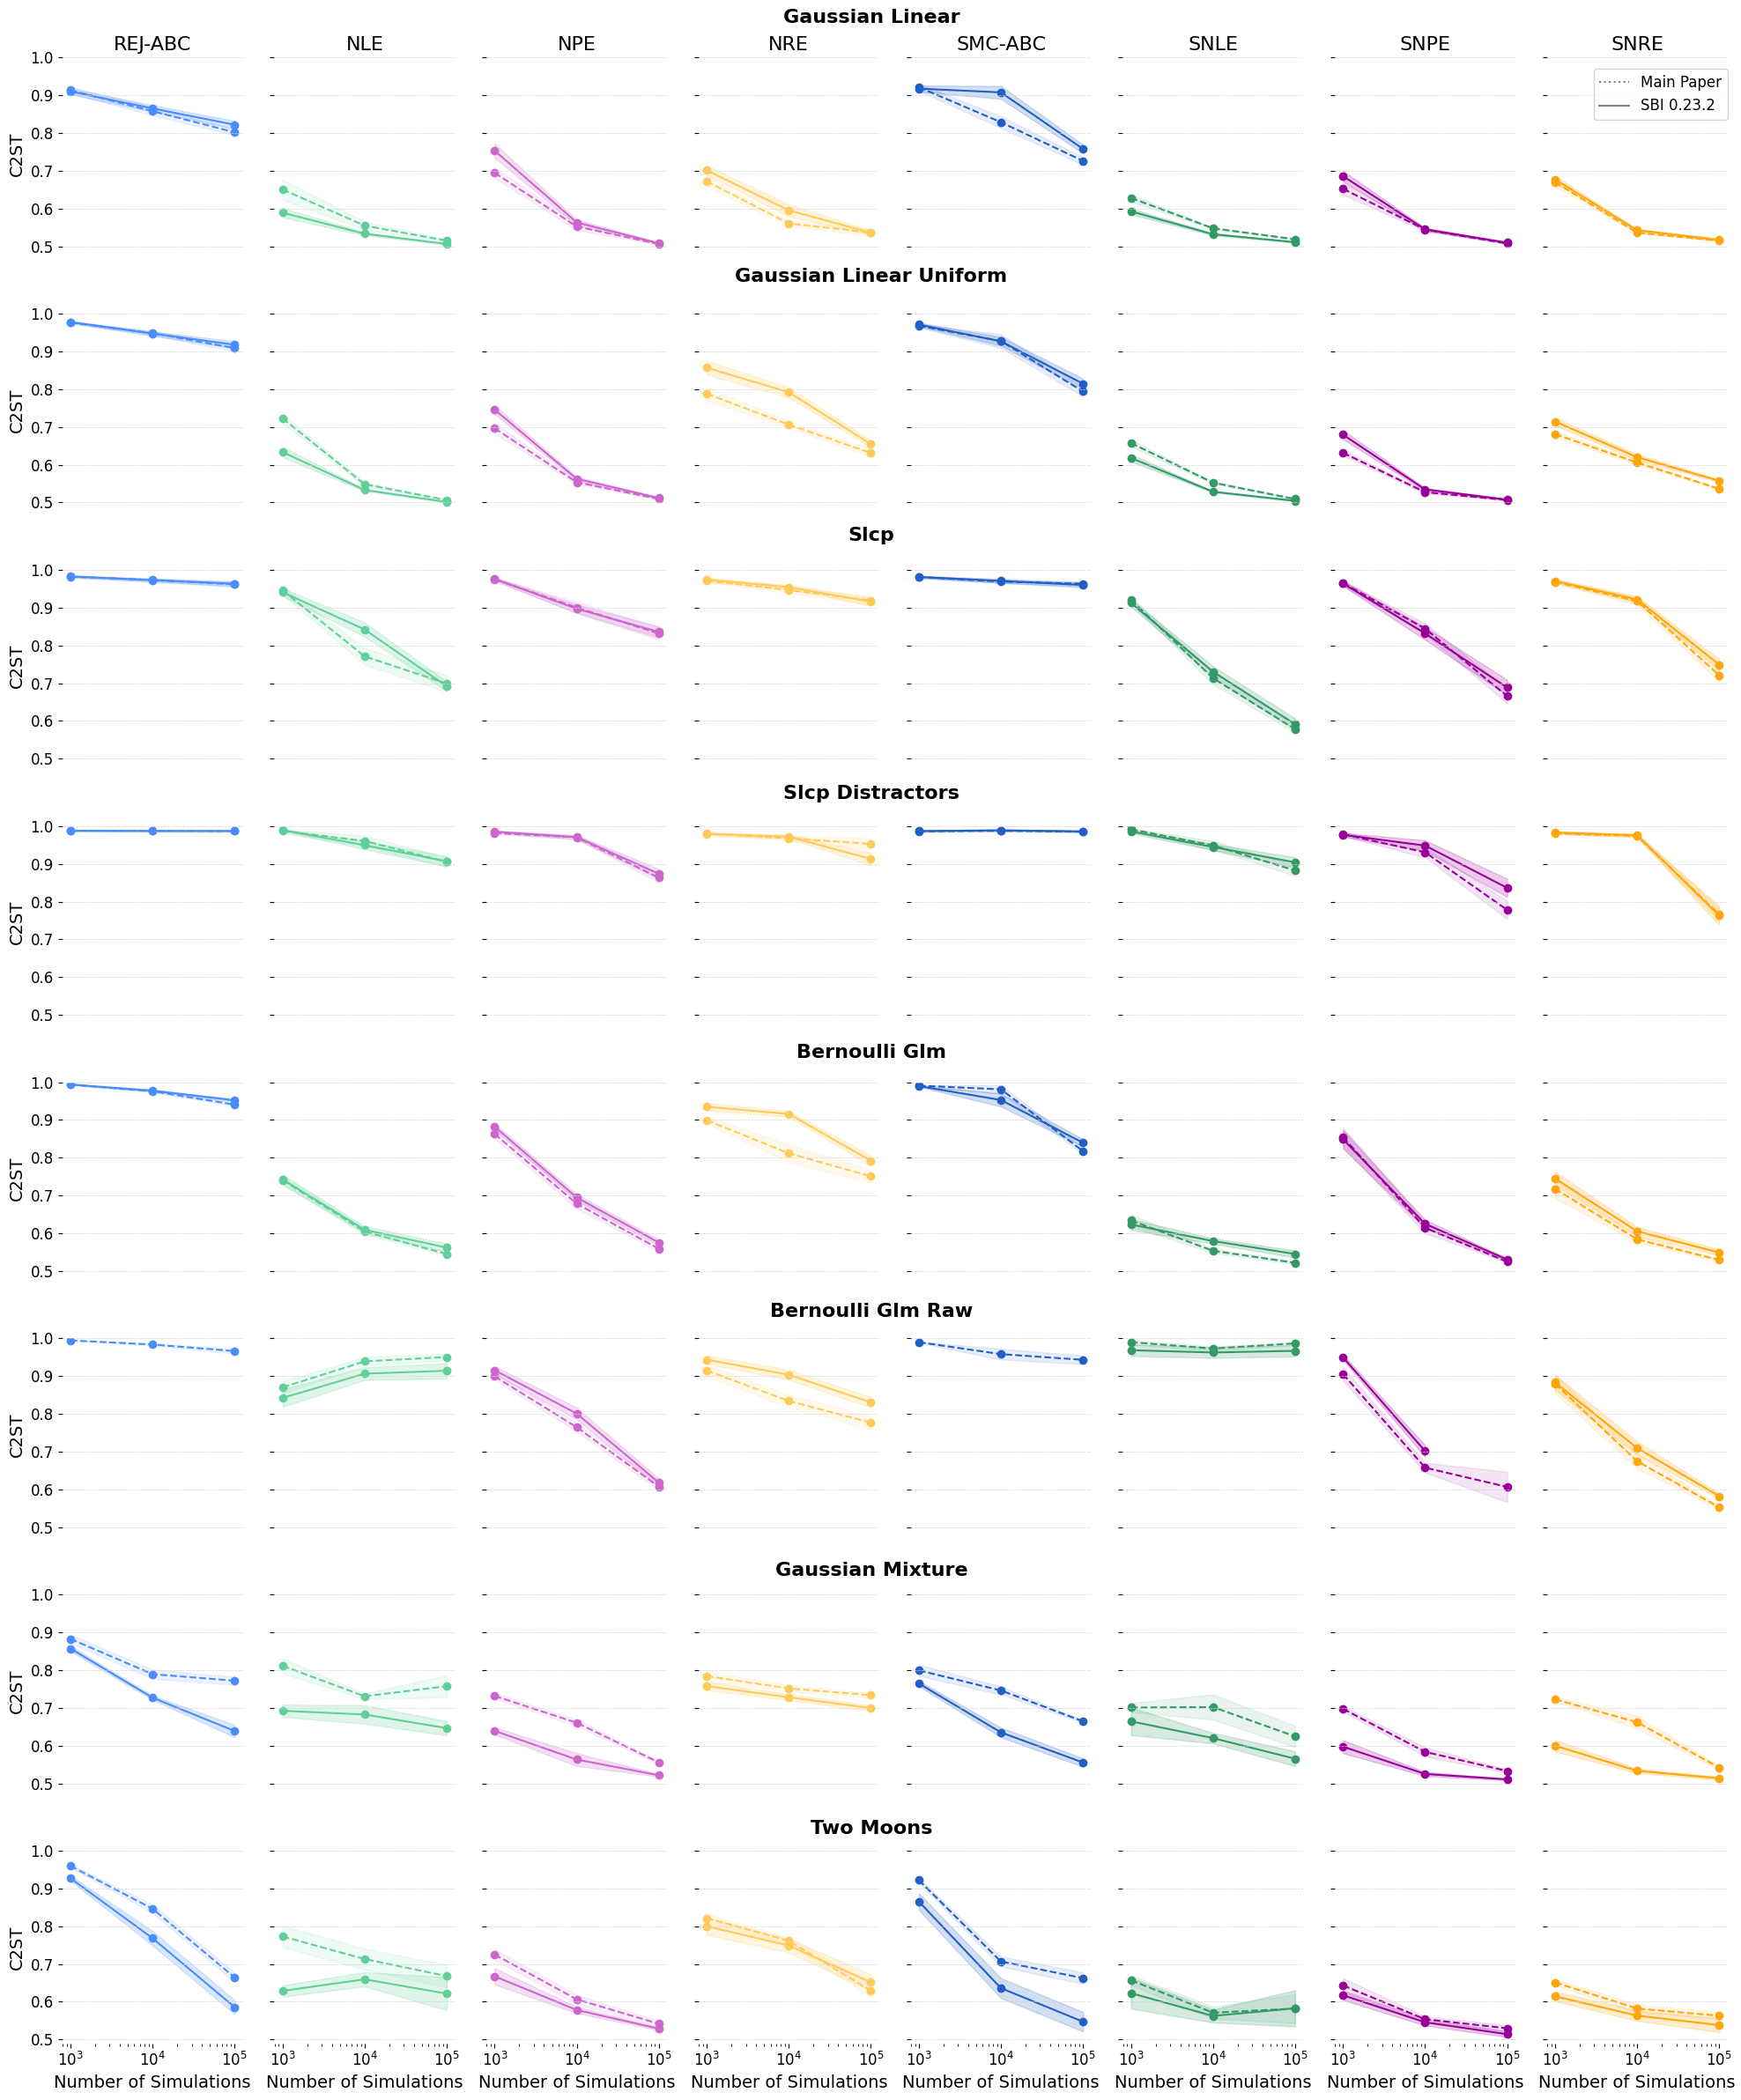

In [14]:
# Create a grid of subplots
fig, axes = plt.subplots(
    len(tasks_order), len(algorithms_order), figsize=(20, 25), sharex=True, sharey=True
)

# Plot the results
for i, task in enumerate(tasks_order):
    for j, algorithm in enumerate(algorithms_order):
        ax = axes[i, j]

        for k, grouped_df in enumerate(grouped_dataframes):
            task_data = grouped_df[
                (grouped_df["task"] == task) & (grouped_df["algorithm"] == algorithm)
            ]

            if not task_data.empty:
                linestyle = (
                    "-" if k == 0 else "--"
                )  # Solid line for the first DataFrame, dashed for others
                alpha = (
                    0.2 if k == 0 else 0.1
                )  # Different alpha for the first DataFrame and others
                label_suffix = (
                    " mean" if k == 0 else " old mean"
                )  # Different label suffix for the first DataFrame and others

                ax.plot(
                    task_data["num_simulations"],
                    task_data["mean"],
                    marker="o",
                    linestyle=linestyle,
                    label=f"{algorithm}{label_suffix}",
                    color=COLORS[algorithm],
                )
                ax.fill_between(
                    task_data["num_simulations"],
                    task_data["mean"] - task_data["sem"],
                    task_data["mean"] + task_data["sem"],
                    color=COLORS[algorithm],
                    alpha=alpha,
                )

        # Remove axis boundaries
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(False)

        # Add horizontal lines for different C2ST levels
        for level in np.arange(0.5, 1.1, 0.1):
            ax.axhline(y=level, color="lightgray", linestyle="--", linewidth=0.5)

        # Set y-limits
        ax.set_ylim(0.49, 1.0)

        # Set x-scale to log
        ax.set_xscale("log")

        if i == 0:
            ax.set_title(algorithm)
        if j == 0:
            ax.set_ylabel("C2ST")
        if i == len(tasks_order) - 1:
            ax.set_xlabel("Number of Simulations")
        else:
            # remove x-axis completely
            ax.set_xticks([])
            # remove ticks and labels
            ax.tick_params(axis="x", which="both", bottom=False, top=False)

# Add task names as intermediate and bold titles in the middle of each row
for i, task in enumerate(tasks_order):
    iy = 0.95 - (i * 0.1175)
    fig.text(
        0.5,
        iy,
        task.replace("_", " ").title(),
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
    )

# Create custom legend handles with grey color, different line styles
import matplotlib.lines as mlines

handle_dotted = mlines.Line2D([], [], color="grey", linestyle=":", label="Main Paper")
handle_solid = mlines.Line2D([], [], color="grey", linestyle="-", label="SBI 0.23.2")

# Add the legend to the figure in the top-right corner with custom handles

fig.legend(
    [handle_dotted, handle_solid],
    ["Main Paper", "SBI 0.23.2"],
    loc="upper right",
    bbox_to_anchor=(0.99, 0.93),
    bbox_transform=fig.transFigure,
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()